<a href="https://colab.research.google.com/github/TanujaMore27/Deep-Learning/blob/main/14.weigthInitializationTechniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Weight Initialization Techniques :

#### Why weight initialization is important?
* if we initializae the weight wrongly at the starting of the neural network then the following problems will be arise :
1. Vanishing Gradient Problem
2. Exploding gradient problem
3. Slow Convergence

in 2000's research on DL stopped due to vanishing gradient problem , then by research it was found that the cause is due to Sigmoid activation function and due to Wrong weight initialization.














***** What not to do? *******

case 1 : Zero Initialization :

* setting all weights and biases initialize with zero.
* lets if we take relu activation function due to zero weights and bias the weighted sum becomes zero and the activation function value also becomes zero hence no training happens due to derivative for new weights becomes zero too.
* in case of tanh function due to exponents the activation function again becomes zero so no training.
* ss of sigmoid
* in case of sigmoid , the activation function at zero becomes 0.5 but for two hidden layers the value of activation function remains same that is 0.5 which was also in the above scenarios. the partial derivatives will remain same except the last term of net weight where only different input values will be multiplied but there also the each input nodes has many connections but due to same activation function result all the weights from each input node connections will remain same acting like there is only one neuron as for that input all connections has same weight.so it will not solve non linear problems making it linear / perceptron model.

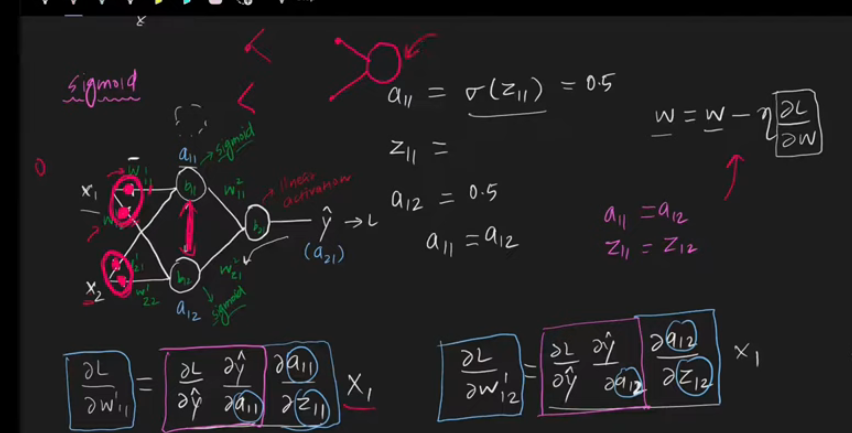

case 2 : non zero constant weight initialization :
* lets weights and biases = 0.5
* so again due to this the value of activation functions becomes same resulting in all nodes acting like a single neuron.
* so we have to randomly initialize the weights

case 3.A : Random Initialization(with small values) :
* according to the ss all the activation functions will be close to zero.hence during the backpropagation the derivatives of this small activation values will be too small closed to zero .
* so in case of tanh there will be big VGP , in case of sigmoid there will be some sort of low VGP than tanh and in case of relu there will be no VGP but there will be slow convergence.

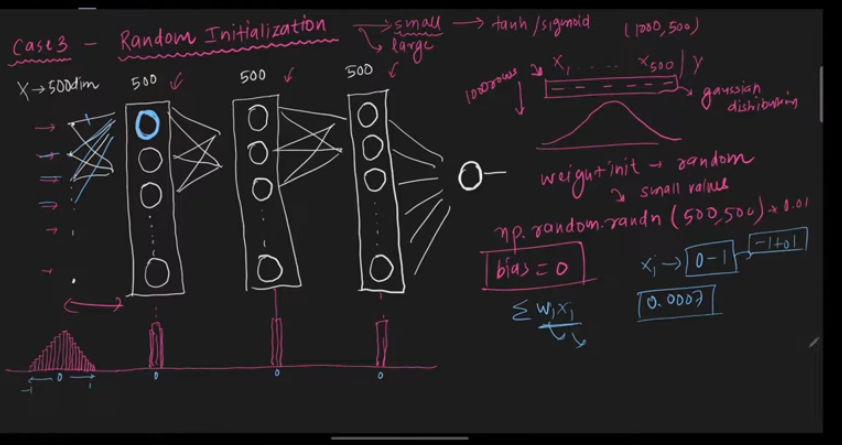

case 3.B : Random Initialization(with large values) :
* the big numbers in DL are between 0 to 1,bcoz the net weight will be 100-500 in values which is quite big.
* by using tanh or sigmoid the sigma of then will be big number so there will be saturation.results in VGP and slow training
* in case of relu as there is no saturation happens the changes will be big in weight updation so we get unstable gradient and will not get to the correct solution.

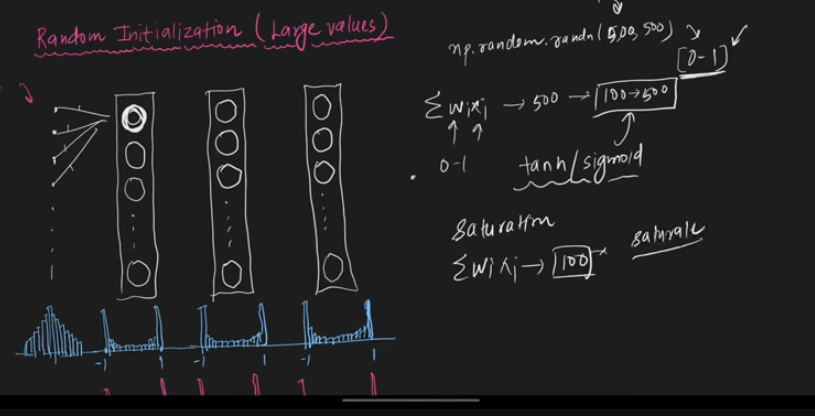

***** What can be do? *******
* code :

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DL/dataset/ushape.csv')
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


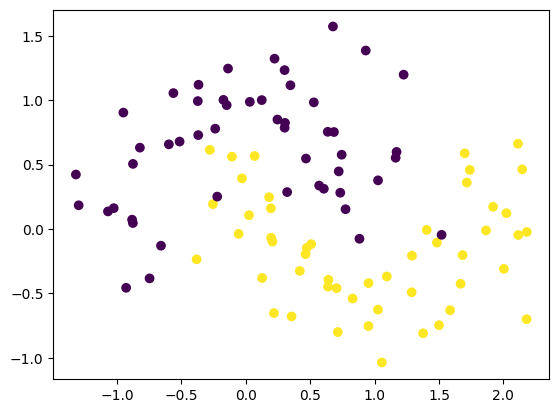

In [ ]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [ ]:
x = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [ ]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.get_weights()

[array([[-1.2029084 , -0.5376958 , -0.40088752, -1.4771448 , -0.9277411 ,
          1.1261541 ,  0.3248446 ,  0.14629476, -0.96082133,  0.01490912],
        [ 2.0675952 , -1.8026195 , -0.1796465 , -1.3327013 , -0.4879215 ,
          0.68555677,  0.17495249,  1.011654  , -1.025307  , -1.5145885 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.8443346 ,  0.25266868, -0.07390333,  0.20812725, -0.9812868 ,
          0.4527933 , -0.40945572,  0.15511622,  0.06664757, -0.1793931 ],
        [-0.4474425 ,  0.5387265 ,  0.01922037,  0.17009486,  0.10354923,
         -0.5009266 , -0.5168701 ,  0.5853786 , -0.5933513 , -0.9415461 ],
        [ 0.35839736,  0.6098363 ,  0.20154718,  0.15746418, -0.06302967,
         -0.41523787,  0.55066353, -0.6406311 , -0.8669342 , -0.6118918 ],
        [ 0.24636562,  0.468132  , -0.14854024,  0.01323036, -0.2073636 ,
          0.5750228 ,  0.25854072, -0.37683982,  0.15143506, -0.67017573],
        [ 0.33137

In [ ]:
initial_weights = model.get_weights()

In [ ]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [ ]:
model.set_weights(initial_weights)

In [ ]:
model.get_weights()

[array([[-0.24768412,  0.4940969 ,  0.78754854, -1.089796  , -0.34555116,
          0.42617768,  0.40184912, -0.636051  ,  0.26147503,  0.16544878],
        [ 0.6079608 , -0.2835821 , -0.00585449,  0.2881106 , -1.2717224 ,
          0.5576304 ,  1.3241966 , -1.4589516 , -0.23630704,  0.1807708 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 1.99539766e-01, -2.83161163e-01, -1.54645398e-01,
         -6.39888525e-01,  1.50615992e-02, -4.85644102e-01,
         -1.52155021e-02, -6.36616023e-03,  1.14340127e-01,
         -1.90797541e-02],
        [ 4.46167976e-01,  1.59705684e-01, -5.06950438e-01,
         -7.99223036e-02,  2.70851344e-01, -1.74377829e-01,
         -3.49812731e-02,  2.82948967e-02, -3.39171827e-01,
         -3.66741031e-01],
        [ 2.69327700e-01,  2.50960022e-01,  4.14044149e-02,
          3.75569835e-02, -2.29979575e-01, -3.44903469e-01,
         -1.21836573e-01,  1.85838237e-01,  3.44170779e-01,
          2.1784754

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])


In [ ]:
history = model.fit(x,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.5125 - loss: 0.6918 - val_accuracy: 0.6500 - val_loss: 0.6893
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6250 - loss: 0.6893 - val_accuracy: 0.6500 - val_loss: 0.6862
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7000 - loss: 0.6862 - val_accuracy: 0.6500 - val_loss: 0.6823
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7375 - loss: 0.6835 - val_accuracy: 0.6500 - val_loss: 0.6785
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7750 - loss: 0.6804 - val_accuracy: 0.7500 - val_loss: 0.6745
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8250 - loss: 0.6771 - val_accuracy: 0.8000 - val_loss: 0.6704
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8375 - loss: 0.6735 - val_accuracy: 0.8500 - val_loss: 0.6657
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8625 - loss: 0.6694 - val_accuracy: 0.9500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 763us/step


<Axes: >

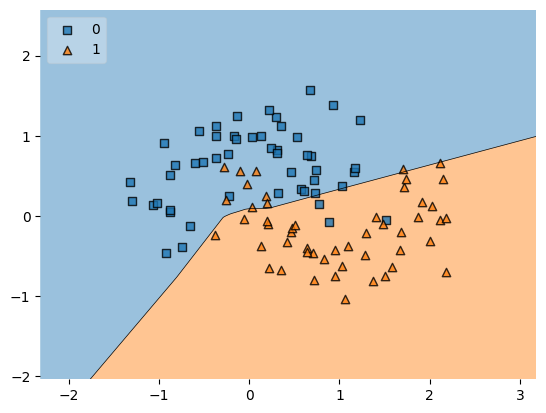

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x,y.astype('int'),clf=model,legend=2)

In [ ]:
(np.random.randn(10,10)*0.01).min()

In [ ]:
(np.random.randn(10,10)*0.01).max()

* there are some heuristic approaches -

instead of multiplying the random values of weight by 0.01 or 1 we multiply it by S.D , where the range of it is the variance = 1/n , here n is number of inputs given to the current node .

 intuition : if n is greater i.e more the inputs then 1/n becomes smaller so less value of weights and vice versa.

1.  Xavier initialization in neural network :
* better results for tanh and sigmoid(for xavier normal)
* for xavier normal formula(same intuition as above)

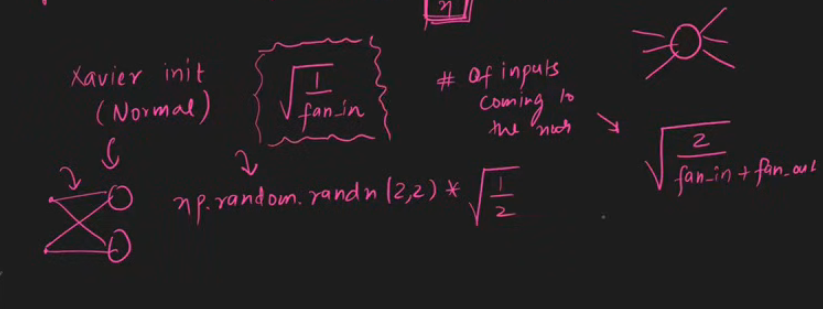


2.  He initialization in neural network:
* better results for relu(for He normal)
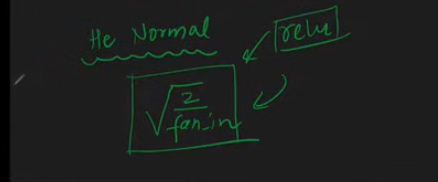

**** formula for both based on Uniform Distribution :

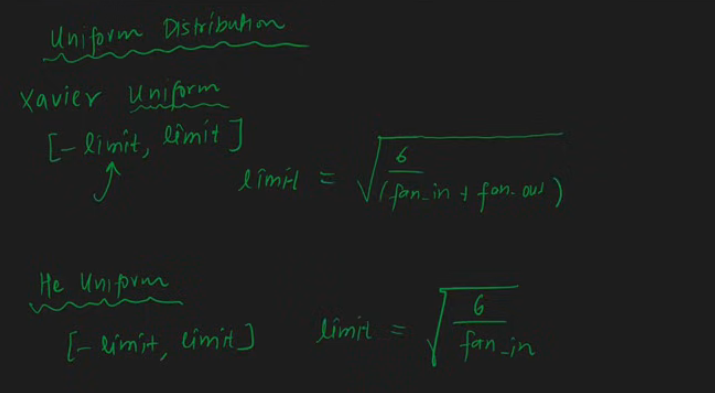